# Actividad 4 — Calidad · NASA POWER

**Objetivo:** Auditar la calidad del dataset climatico: nulos, valores centinela -999, rangos fisicos, saltos temporales y consistencia geografica.


## Configuracion inicial


In [1]:
import os, sys, json, glob, warnings, unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

while not os.path.exists('pipeline/config/pipeline_config.json'):
    os.chdir('..')
with open('pipeline/config/pipeline_config.json','r',encoding='utf-8') as f:
    CONFIG = json.load(f)
SOURCES = CONFIG['sources']
OUTPUT  = CONFIG['output']

def normalizar(t):
    if not isinstance(t, str): return ''
    t = unicodedata.normalize('NFKD', t).encode('ASCII','ignore').decode('utf-8')
    return t.upper().strip()

def reporte_nulos(df, nombre):
    nulos = df.isnull().sum()
    pct   = (nulos / len(df) * 100).round(2)
    r = pd.DataFrame({'nulos': nulos, 'pct': pct})
    r = r[r['nulos'] > 0].sort_values('nulos', ascending=False)
    print(f'=== NULOS EN {nombre} ===')
    if len(r) == 0:
        print('  Sin valores nulos.')
    else:
        print(r.to_string())
    print()
    return r

def outliers_iqr(serie, nombre):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    mask = (serie < lower) | (serie > upper)
    n_out = mask.sum()
    pct = n_out / len(serie) * 100
    print(f'{nombre}: Q1={Q1:.2f} Q3={Q3:.2f} IQR={IQR:.2f}')
    print(f'  Limite inferior: {lower:.2f} | Limite superior: {upper:.2f}')
    print(f'  Outliers: {n_out} ({pct:.2f}%)')
    return lower, upper, mask

print('Config cargado OK | Raiz:', os.getcwd())


Config cargado OK | Raiz: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-


## Carga de datos


In [2]:
df_nasa = pd.read_csv(OUTPUT['lectura'] + 'nasa_long_raw.csv', low_memory=False)
VARS_CLIMA = [c for c in df_nasa.columns if c not in ['DEPARTAMENTO','PROVINCIA','YEAR','MES']]
RANGOS = CONFIG.get('RANGOS_VALIDOS', {
    'T2M': [-10.0, 50.0], 'T2M_MAX': [-5.0, 55.0], 'T2M_MIN': [-20.0, 40.0],
    'PRECTOTCORR': [0.0, 50.0], 'RH2M': [0.0, 100.0], 'QV2M': [0.0, 30.0],
    'ALLSKY_SFC_SW_DWN': [0.0, 35.0], 'WS2M': [0.0, 20.0]
})
print(f'Shape: {df_nasa.shape}')
print(f'Variables climaticas: {VARS_CLIMA}')


Shape: (6120, 12)
Variables climaticas: ['ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'QV2M', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'WS2M']


## 4.1 Auditoria de Nulos por Variable


=== NULOS POR VARIABLE CLIMATICA ===
  ALLSKY_SFC_SW_DWN           102 nulos (1.67%)  [REQUIERE IMPUTACION]
  PRECTOTCORR                   0 nulos (0.00%)  [OK]
  QV2M                          0 nulos (0.00%)  [OK]
  RH2M                          0 nulos (0.00%)  [OK]
  T2M                           0 nulos (0.00%)  [OK]
  T2M_MAX                       0 nulos (0.00%)  [OK]
  T2M_MIN                       0 nulos (0.00%)  [OK]
  WS2M                          0 nulos (0.00%)  [OK]


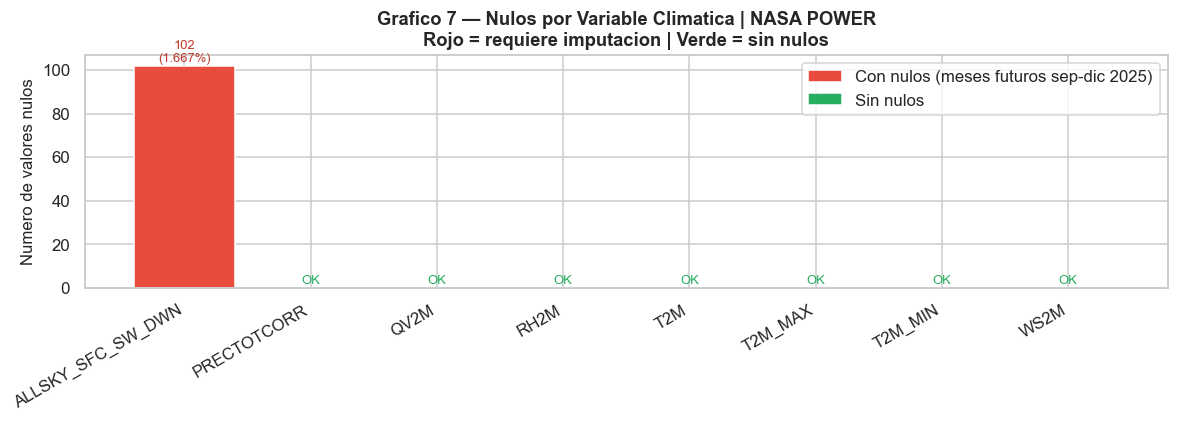

Guardado: pipeline/output/04_calidad/act04_nasa_g7_nulos.png


In [3]:
nulos_nasa = df_nasa[VARS_CLIMA].isnull().sum()
pct_nasa   = (nulos_nasa / len(df_nasa) * 100).round(3)

print('=== NULOS POR VARIABLE CLIMATICA ===')
for var, n, p in zip(nulos_nasa.index, nulos_nasa.values, pct_nasa.values):
    nivel = 'REQUIERE IMPUTACION' if n > 0 else 'OK'
    print(f'  {var:<25} {n:>5,} nulos ({p:.2f}%)  [{nivel}]')

# Grafico G7
fig, ax = plt.subplots(figsize=(11, 4))
colors_n = ['#e74c3c' if n > 0 else '#27ae60' for n in nulos_nasa.values]
bars = ax.bar(nulos_nasa.index, nulos_nasa.values, color=colors_n, edgecolor='white')
for bar, val, p in zip(bars, nulos_nasa.values, pct_nasa.values):
    label = f'{val}\n({p}%)' if val > 0 else 'OK'
    color = '#c0392b' if val > 0 else '#27ae60'
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.3 if val > 0 else 0.3,
            label, ha='center', va='bottom', fontsize=8.5, color=color)
ax.set_ylabel('Numero de valores nulos', fontsize=11)
ax.set_title('Grafico 7 — Nulos por Variable Climatica | NASA POWER\n'
             'Rojo = requiere imputacion | Verde = sin nulos',
             fontsize=12, fontweight='bold')
ax.set_xticklabels(nulos_nasa.index, rotation=30, ha='right')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#e74c3c', label='Con nulos (meses futuros sep-dic 2025)'),
                   Patch(facecolor='#27ae60', label='Sin nulos')])
plt.tight_layout()
g = OUTPUT['calidad'] + 'act04_nasa_g7_nulos.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Decision tecnica documentada

**Problema:** 102 nulos en ALLSKY_SFC_SW_DWN (meses futuros sep-dic 2025 sin datos NASA)  
**Magnitud:** 102 registros (1.7% de la variable)  
**Decision (Actividad 5):** En la Actividad 5 se imputara con interpolacion lineal (<=4 meses consecutivos por provincia).


## 4.2 Verificacion de Valores Centinela -999


In [4]:
print('=== VERIFICACION DE VALORES CENTINELA -999 ===')
centinelas = {}
for var in VARS_CLIMA:
    n_centinela = (df_nasa[var] == -999.0).sum()
    centinelas[var] = n_centinela
    if n_centinela > 0:
        print(f'  ALERTA: {var} tiene {n_centinela} valores -999 sin convertir a NaN')

total_centinelas = sum(centinelas.values())
if total_centinelas == 0:
    print('  OK: No se encontraron valores centinela -999 en ninguna variable.')
    print('  Los valores -999 fueron correctamente convertidos a NaN en la Actividad 2.')
else:
    print(f'  TOTAL centinelas residuales: {total_centinelas}')


=== VERIFICACION DE VALORES CENTINELA -999 ===
  OK: No se encontraron valores centinela -999 en ninguna variable.
  Los valores -999 fueron correctamente convertidos a NaN en la Actividad 2.


### Decision tecnica documentada

**Problema:** Valores centinela -999 de NASA POWER para datos no disponibles  
**Magnitud:** Ver resultado arriba — si hay residuales, cuantificar  
**Decision (Actividad 5):** En la Actividad 5 se aplicara df.replace(-999.0, np.nan) como medida de seguridad.


## 4.3 Verificacion de Rangos Fisicos


=== VERIFICACION DE RANGOS FISICOS ===
  ALLSKY_SFC_SW_DWN         rango [0.0, 35.0]  violaciones: 0  [OK]
  PRECTOTCORR               rango [0.0, 50.0]  violaciones: 0  [OK]
  QV2M                      rango [0.0, 30.0]  violaciones: 0  [OK]
  RH2M                      rango [0.0, 100.0]  violaciones: 0  [OK]
  T2M                       rango [-10.0, 50.0]  violaciones: 0  [OK]
  T2M_MAX                   rango [-5.0, 55.0]  violaciones: 0  [OK]
  T2M_MIN                   rango [-20.0, 40.0]  violaciones: 0  [OK]
  WS2M                      rango [0.0, 20.0]  violaciones: 0  [OK]


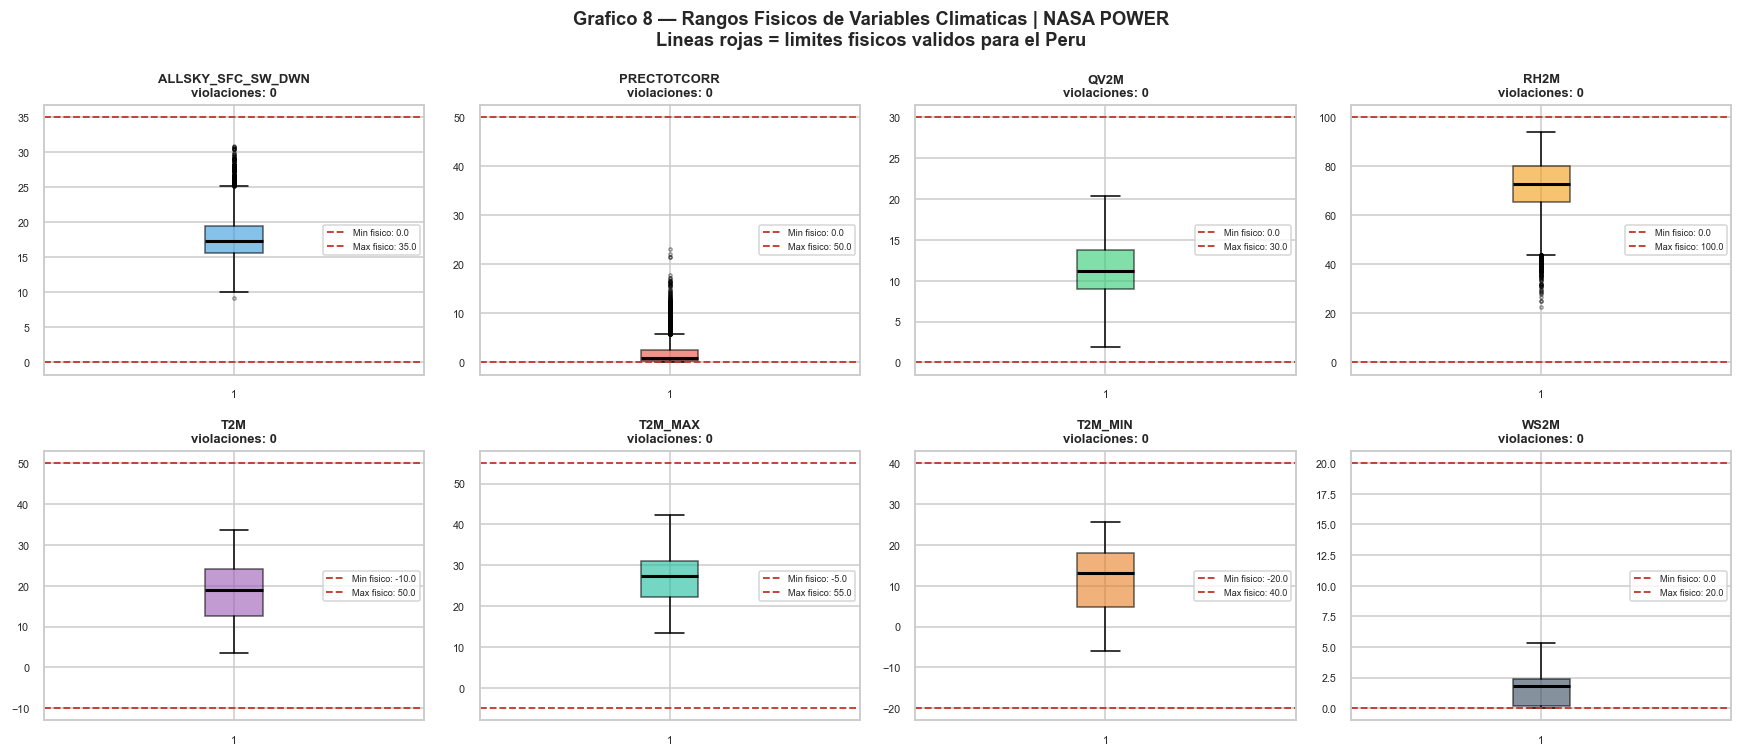

Guardado: pipeline/output/04_calidad/act04_nasa_g8_rangos.png


In [5]:
print('=== VERIFICACION DE RANGOS FISICOS ===')
violaciones = {}
for var in VARS_CLIMA:
    if var in RANGOS:
        rmin, rmax = RANGOS[var]
        data = df_nasa[var].dropna()
        fuera = ((data < rmin) | (data > rmax)).sum()
        violaciones[var] = fuera
        estado = 'ALERTA' if fuera > 0 else 'OK'
        print(f'  {var:<25} rango [{rmin}, {rmax}]  '
              f'violaciones: {fuera}  [{estado}]')

# Grafico G8: boxplots con limites fisicos
n_vars = len(VARS_CLIMA)
ncols = 4
nrows = (n_vars + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows*3.5))
axes = axes.flatten()
colores_box = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22','#34495e']

for i, (var, color) in enumerate(zip(VARS_CLIMA, colores_box)):
    data = df_nasa[var].dropna()
    bp = axes[i].boxplot(data, patch_artist=True, vert=True,
                         boxprops=dict(facecolor=color, alpha=0.6),
                         medianprops=dict(color='black', linewidth=2),
                         flierprops=dict(marker='o', color='#e74c3c',
                                         markersize=2, alpha=0.4))
    if var in RANGOS:
        rmin, rmax = RANGOS[var]
        axes[i].axhline(rmin, color='#c0392b', linestyle='--', linewidth=1.2,
                        label=f'Min fisico: {rmin}')
        axes[i].axhline(rmax, color='#c0392b', linestyle='--', linewidth=1.2,
                        label=f'Max fisico: {rmax}')
    axes[i].set_title(f'{var}\nviolaciones: {violaciones.get(var,0)}',
                      fontsize=8.5, fontweight='bold')
    axes[i].tick_params(labelsize=7)
    axes[i].legend(fontsize=6)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Grafico 8 — Rangos Fisicos de Variables Climaticas | NASA POWER\n'
             'Lineas rojas = limites fisicos validos para el Peru',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['calidad'] + 'act04_nasa_g8_rangos.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Decision tecnica documentada

**Problema:** Valores fuera de rangos fisicos posibles para el Peru  
**Magnitud:** Ver tabla de violaciones arriba  
**Decision (Actividad 5):** En la Actividad 5 se aplicara clipping a los rangos validos definidos en pipeline_config.json.


## 4.4 Saltos Temporales por Provincia


Meses esperados por provincia: 60
Provincias con serie completa: 102
Provincias con serie incompleta: 0


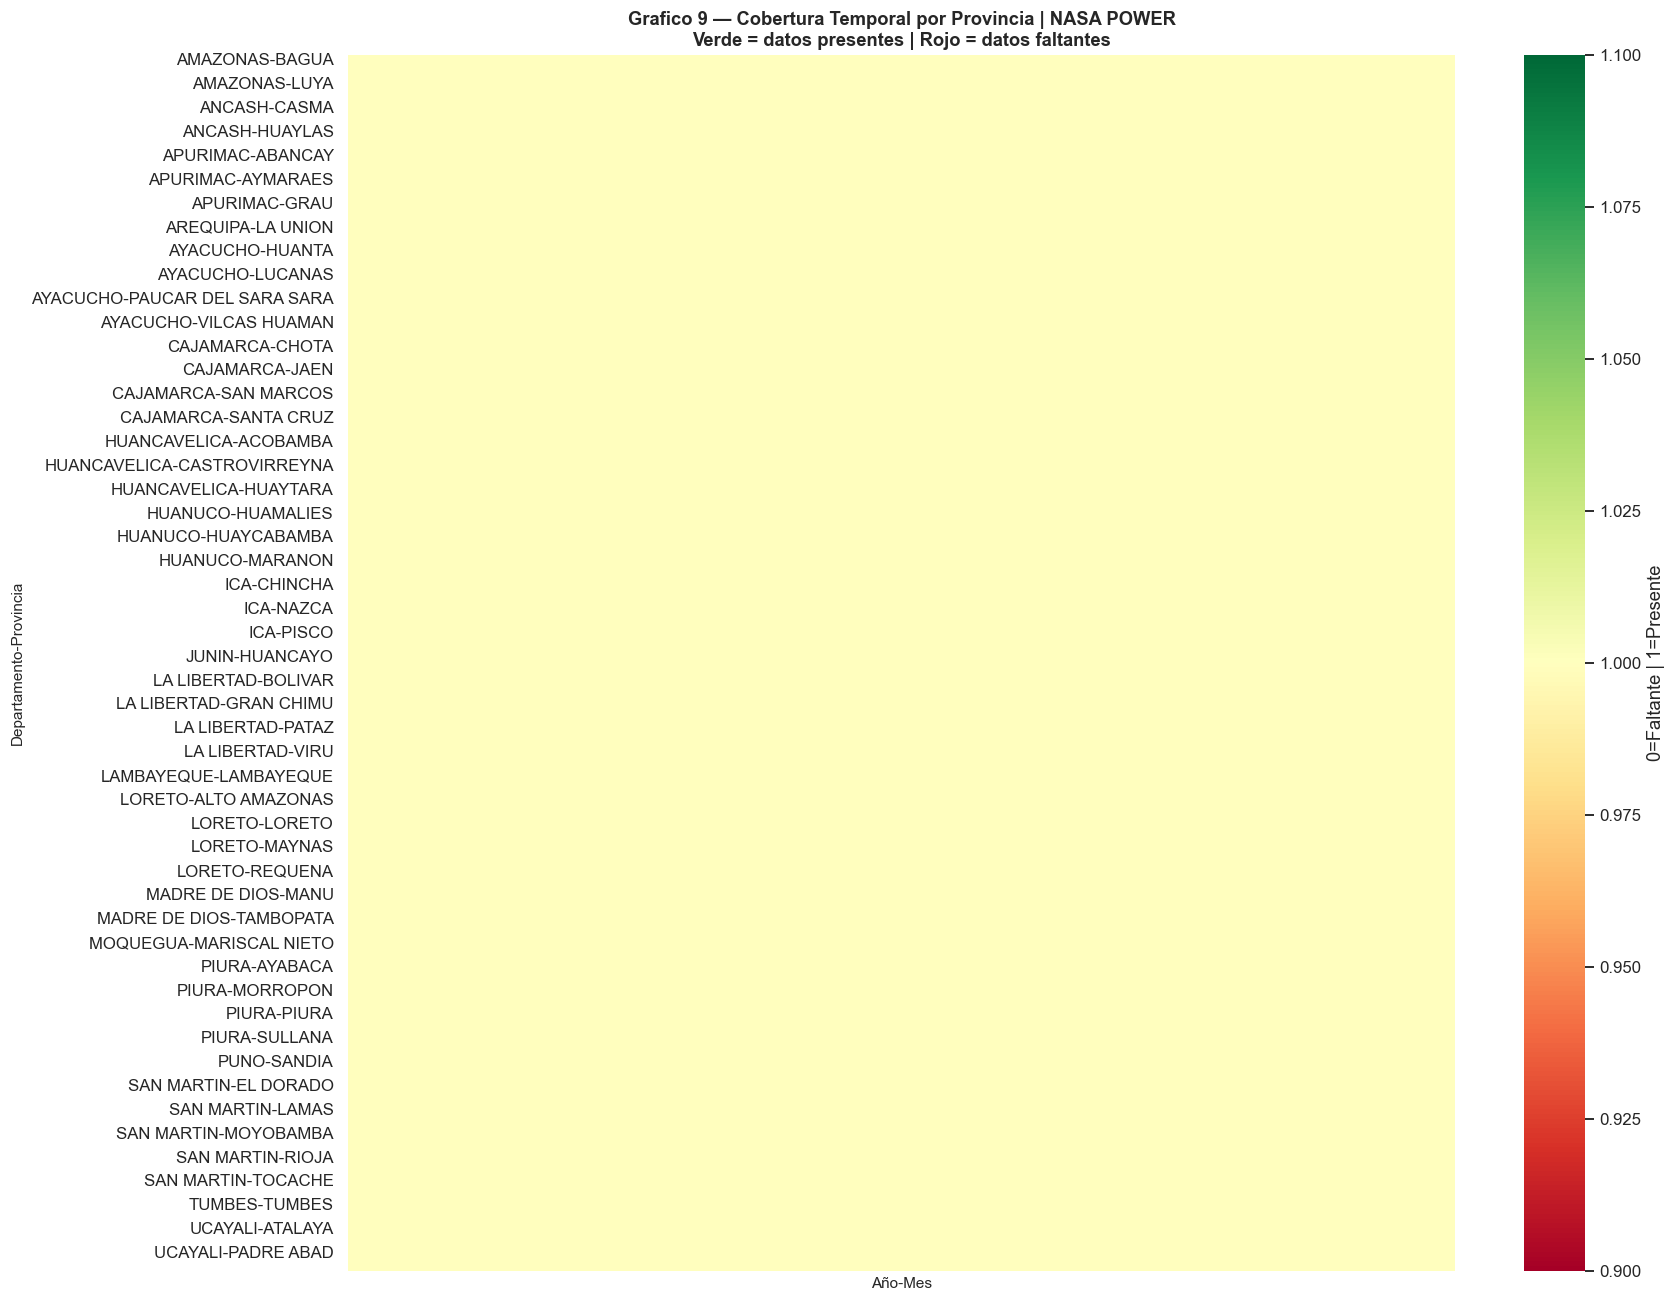

Guardado: pipeline/output/04_calidad/act04_nasa_g9_cobertura.png


In [6]:
# Verificar que cada provincia tiene los 60 meses esperados (2021-01 a 2025-12)
meses_esperados = 60  # 5 años x 12 meses
meses_por_prov = df_nasa.groupby(['DEPARTAMENTO','PROVINCIA']).size()

incompletas = meses_por_prov[meses_por_prov < meses_esperados]
completas   = meses_por_prov[meses_por_prov == meses_esperados]

print(f'Meses esperados por provincia: {meses_esperados}')
print(f'Provincias con serie completa: {len(completas)}')
print(f'Provincias con serie incompleta: {len(incompletas)}')
if len(incompletas) > 0:
    print()
    print('Provincias incompletas:')
    print(incompletas.to_string())

# Grafico G9: heatmap cobertura por provincia
cobertura_prov = df_nasa.groupby(['DEPARTAMENTO','PROVINCIA','YEAR','MES']).size().unstack(
    level=['YEAR','MES'], fill_value=0)
cobertura_bool = (cobertura_prov > 0).astype(int)

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(cobertura_bool, cmap='RdYlGn', ax=ax,
            xticklabels=False,
            cbar_kws={'label': '0=Faltante | 1=Presente'})
ax.set_title('Grafico 9 — Cobertura Temporal por Provincia | NASA POWER\n'
             'Verde = datos presentes | Rojo = datos faltantes',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Año-Mes', fontsize=10)
ax.set_ylabel('Departamento-Provincia', fontsize=10)
plt.tight_layout()
g = OUTPUT['calidad'] + 'act04_nasa_g9_cobertura.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Decision tecnica documentada

**Problema:** Provincias con series temporales incompletas  
**Magnitud:** Ver tabla de provincias incompletas arriba  
**Decision (Actividad 5):** En la Actividad 5 se imputaran los meses faltantes con interpolacion lineal o media historica.


In [7]:
reporte = [
    'REPORTE DE CALIDAD — NASA POWER',
    '=' * 60,
    f'Registros totales: {len(df_nasa):,}',
    f'Variables climaticas: {len(VARS_CLIMA)}',
    f'Provincias: {df_nasa["PROVINCIA"].nunique()}',
    f'Centinelas -999 residuales: {total_centinelas}',
    f'Provincias con serie completa: {len(completas)}',
    f'Provincias con serie incompleta: {len(incompletas)}',
]
for var, n in nulos_nasa.items():
    if n > 0:
        reporte.append(f'Nulos {var}: {n} ({pct_nasa[var]:.2f}%)')
for var, n in violaciones.items():
    if n > 0:
        reporte.append(f'Violaciones rango {var}: {n}')

reporte_txt = '\n'.join(reporte)
print(reporte_txt)
with open(OUTPUT['calidad'] + 'reporte_calidad_nasa.txt', 'w', encoding='utf-8') as f:
    f.write(reporte_txt)
print()
print('[ACTIVIDAD 4 - NASA] COMPLETADA.')


REPORTE DE CALIDAD — NASA POWER
Registros totales: 6,120
Variables climaticas: 8
Provincias: 102
Centinelas -999 residuales: 0
Provincias con serie completa: 102
Provincias con serie incompleta: 0
Nulos ALLSKY_SFC_SW_DWN: 102 (1.67%)

[ACTIVIDAD 4 - NASA] COMPLETADA.
